# Check Point 2 Final Project SISTECH 2026 — Machine Learning Operations
## Model Training & Baseline Comparison

Input yang dipakai di sini adalah `features_labels.csv`,
output dari CP1: satu baris = satu kombinasi **(sel grid, hari, jam)** dalam
koordinat proxy Jabodetabek, dengan `risk_score` (0–100) sebagai target yang
mau diprediksi.

**Fokus notebook ini:** bagian *Model Training & Baseline Comparison*

# 0. Setup & Import Library

In [1]:
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42
print("Setup selesai OK")


Setup selesai OK


# 1. Load Dataset Fitur + Label dari CP1

Dataset ini adalah output `features_labels.csv` dari Checkpoint 1: satu baris
= satu kombinasi **(sel grid, hari, jam)** dalam koordinat proxy Jabodetabek,
dengan `risk_score` (0-100) sebagai target yang mau diprediksi.

In [2]:
import gdown

FILE_ID = "1lTMvpT1IKH7wI3ydBOWu0IWJuBeEbyrY"
OUTPUT  = "features_labels.csv"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1lTMvpT1IKH7wI3ydBOWu0IWJuBeEbyrY
To: /content/features_labels.csv
100%|██████████| 15.3M/15.3M [00:00<00:00, 52.5MB/s]


'features_labels.csv'

In [3]:
df = pd.read_csv(OUTPUT)
print("Shape:", df.shape)
print("Jumlah sel unik:", df["cell_id"].nunique())
df.head()


Shape: (119454, 12)
Jumlah sel unik: 1001


,cell_id,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,risk_score
0,-6.11_106.69,-6.11,106.69,0,0,0.000000,1.00000,0.000000e+00,1.000000,1,0.0,34.989507
1,-6.11_106.69,-6.11,106.69,0,3,0.000000,1.00000,7.071068e-01,0.707107,1,0.0,28.500710
2,-6.11_106.69,-6.11,106.69,0,12,0.000000,1.00000,1.224647e-16,-1.000000,3,0.0,23.418378
3,-6.11_106.69,-6.11,106.69,0,15,0.000000,1.00000,-7.071068e-01,-0.707107,1,0.0,10.415326
4,-6.11_106.69,-6.11,106.69,1,9,0.781831,0.62349,7.071068e-01,-0.707107,1,0.0,37.168742


In [4]:
# Diagnosa NaN sebelum lanjut
print("Jumlah NaN per kolom:")
print(df.isna().sum())

n_nan_target = df["risk_score"].isna().sum()
print(f"\nBaris dengan risk_score NaN: {n_nan_target} dari {len(df)} ({n_nan_target/len(df)*100:.2f}%)")


Jumlah NaN per kolom:
cell_id        0
lat_r          0
lon_r          0
dow            0
hour           0
dow_sin        0
dow_cos        0
hour_sin       0
hour_cos       0
crime_count    0
arrest_rate    0
risk_score     0
dtype: int64

Baris dengan risk_score NaN: 0 dari 119454 (0.00%)


In [5]:
before = len(df)
df = df.dropna(subset=["risk_score"]).reset_index(drop=True)
after = len(df)
print(f"Baris dibuang karena risk_score NaN: {before - after} ({(before-after)/max(before,1)*100:.2f}%)")
print(f"Sisa baris: {after}")


Baris dibuang karena risk_score NaN: 0 (0.00%)
Sisa baris: 119454


In [6]:
df.dtypes

,0
cell_id,object
lat_r,float64
lon_r,float64
dow,int64
hour,int64
dow_sin,float64
dow_cos,float64
hour_sin,float64
hour_cos,float64
crime_count,int64


Tidak ada missing values (wajar, karena ini output agregasi dari CP1, bukan
data mentah). Yang perlu diperhatikan justru bukan kualitas datanya, tapi
**kolom mana yang boleh dipakai sebagai fitur** — dibahas di Bab 3.

# 2. Baseline — Patokan Minimal

Sebelum melatih model ML apapun, kita perlu tahu: **apa prediksi paling
logis yang bisa dibuat tanpa melatih model sama sekali?** Ada dua kandidat:

1. **Global mean** — selalu menebak rata-rata `risk_score` dari seluruh data
   training, tidak peduli sel/waktu. Ini "patokan mutlak" ala `DummyRegressor`.
2. **Rata-rata historis per sel** — menebak rata-rata `risk_score` sel itu
   sendiri (dari data training), tanpa peduli jam/harinya. Ini masih tanpa
   model ML, tapi memakai pola historis yang memang sudah tersedia (persis
   seperti yang diminta di soal: risiko suatu lokasi memang cenderung mirip
   dari waktu ke waktu, karena `risk_score` di CP1 sudah dihaluskan secara
   spasial lewat *spatial smoothing*).

Baseline kedua ini yang dipakai sebagai "lantai" resmi untuk dikalahkan
model-model di Bab 4, karena ini prediksi paling logis yang bisa dibuat murni
dari pola historis tanpa melatih apapun.

In [7]:
feature_cols = ["lat_r", "lon_r", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
target_col = "risk_score"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
train_idx, test_idx = X_train.index, X_test.index

print(f"Training set : {len(X_train):>7,} baris")
print(f"Test set     : {len(X_test):>7,} baris")


Training set :  95,563 baris
Test set     :  23,891 baris


In [8]:
# Baseline 1: global mean (DummyRegressor)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
mae_dummy = mean_absolute_error(y_test, dummy.predict(X_test))
rmse_dummy = np.sqrt(mean_squared_error(y_test, dummy.predict(X_test)))

print(f"Baseline global mean -> selalu menebak: {y_train.mean():.2f}")
print(f"MAE  : {mae_dummy:.3f}")
print(f"RMSE : {rmse_dummy:.3f}")


Baseline global mean -> selalu menebak: 60.07
MAE  : 10.646
RMSE : 13.439


In [9]:
# Baseline 2: rata-rata historis per cell_id (dihitung HANYA dari training set)
cell_mean_lookup = df.loc[train_idx].groupby("cell_id")[target_col].mean()
global_fallback = y_train.mean()  # buat sel yang somehow tidak ada di train (jaga-jaga)

y_pred_cellmean = df.loc[test_idx, "cell_id"].map(cell_mean_lookup).fillna(global_fallback)

mae_cellmean = mean_absolute_error(y_test, y_pred_cellmean)
rmse_cellmean = np.sqrt(mean_squared_error(y_test, y_pred_cellmean))

print(f"Baseline rata-rata per sel")
print(f"MAE  : {mae_cellmean:.3f}")
print(f"RMSE : {rmse_cellmean:.3f}")
print()
print(f"Perbaikan vs global mean: {mae_dummy - mae_cellmean:+.3f} MAE")


Baseline rata-rata per sel
MAE  : 5.653
RMSE : 7.157

Perbaikan vs global mean: +4.993 MAE


### 2.1 Baseline Tambahan — Granularitas Lain

Baseline per sel di atas mengabaikan waktu sepenuhnya. Sebelum lanjut ke model ML,
wajar untuk bertanya: apakah baseline yang **sedikit lebih rinci** (tetap tanpa model ML,
cuma rata-rata historis dengan granularitas berbeda) bisa jadi lantai yang lebih ketat?
Tiga kandidat dicoba:

1. **Per (sel, jam)** — rata-rata risk_score sel ini, khusus jam yang sama (lintas hari).
2. **Per (sel, hari)** — rata-rata risk_score sel ini, khusus hari yang sama (lintas jam).
3. **Per (sel, hari, jam)** — granularitas paling rinci... tapi ini contoh baseline yang
   *keliru dirancang*, dijelaskan di bawah setelah dijalankan.

In [10]:
def eval_group_baseline(group_cols):
    lookup = df.loc[train_idx].groupby(group_cols)[target_col].mean()
    fallback = y_train.mean()
    if len(group_cols) == 1:
        pred = df.loc[test_idx, group_cols[0]].map(lookup).fillna(fallback)
    else:
        keys_test = pd.Series(list(zip(*[df.loc[test_idx, c] for c in group_cols])), index=test_idx)
        pred = keys_test.map(lookup).fillna(fallback)
    mae_ = mean_absolute_error(y_test, pred)
    rmse_ = np.sqrt(mean_squared_error(y_test, pred))
    n_groups = df.groupby(group_cols).ngroups
    return mae_, rmse_, n_groups

baseline_variants = {}
for cols, label in [
    (["cell_id"], "Per sel"),
    (["cell_id", "hour"], "Per (sel, jam)"),
    (["cell_id", "dow"], "Per (sel, hari)"),
    (["cell_id", "dow", "hour"], "Per (sel, hari, jam)"),
]:
    mae_b, rmse_b, ng = eval_group_baseline(cols)
    baseline_variants[label] = {"MAE": mae_b, "RMSE": rmse_b, "n_groups": ng}
    print(f"{label:25s} (n_groups={ng:>7,}) MAE={mae_b:.3f}  RMSE={rmse_b:.3f}")

# Cek eksplisit kenapa baseline per (sel, hari, jam) gagal total
lookup_full = df.loc[train_idx].groupby(["cell_id", "dow", "hour"]).size()
test_keys = list(zip(df.loc[test_idx, "cell_id"], df.loc[test_idx, "dow"], df.loc[test_idx, "hour"]))
matched = sum(1 for k in test_keys if k in lookup_full.index)
print(f"\nBaseline per (sel, hari, jam): dari {len(test_keys):,} baris test, "
      f"hanya {matched} ({matched/len(test_keys)*100:.2f}%) kombinasi yang juga ada di train.")


Per sel                   (n_groups=  1,001) MAE=5.653  RMSE=7.157
Per (sel, jam)            (n_groups= 21,718) MAE=4.071  RMSE=6.072
Per (sel, hari)           (n_groups=  6,715) MAE=5.943  RMSE=7.587
Per (sel, hari, jam)      (n_groups=119,454) MAE=10.646  RMSE=13.439

Baseline per (sel, hari, jam): dari 23,891 baris test, hanya 0 (0.00%) kombinasi yang juga ada di train.


**Hasil aktual & interpretasi:**

| Baseline | Jumlah grup | MAE | RMSE |
|---|---|---|---|
| Global mean | 1 | 10,65 | 13,44 |
| Per sel | 1.001 | 5,65 | 7,16 |
| **Per (sel, jam)** | 21.718 | **4,07** | **6,07** |
| Per (sel, hari) | 6.715 | 5,94 | 7,59 |
| Per (sel, hari, jam) | 119.454 | 10,65 | 13,44 |

- **Per (sel, jam) adalah baseline terbaik** — pola "jam berapa rawan di lokasi ini" (siang
  vs malam) ternyata sinyal yang kuat dan stabil, lebih informatif daripada sekadar identitas
  sel saja.
- **Per (sel, hari) sedikit lebih buruk** dari per-sel polos — pola hari-dalam-minggu
  (weekday vs weekend) di data ini kurang membedakan risiko dibanding pola jam.
- **Per (sel, hari, jam) gagal total** (MAE sama persis dengan global mean) — dan ini bukan
  bug, tapi cara merancang baseline yang keliru: tabel `unit` di CP1 sudah diagregasi ke level
  (sel, hari, jam), sehingga setiap kombinasi itu **hanya muncul satu kali** di seluruh
  dataset. Begitu displit train/test secara acak per baris, 0% kombinasi test yang juga ada
  di train — baseline ini tidak pernah bisa mencocokkan apa pun, jadi selalu jatuh ke
  fallback (global mean). Pelajarannya: baseline historis tidak boleh dibuat sama persis
  dengan level agregasi data itu sendiri, karena tidak ada pengulangan yang bisa dipelajari.

**Baseline per (sel, jam) (MAE 4,07) dipakai sebagai lantai resmi yang baru** — lebih ketat
dari sekadar per-sel, jadi standar yang harus dikalahkan model-model di Bab 4 juga lebih
tinggi.

# 3. Feature Vector Assembly

## 3.1 Fitur yang aman dipakai

Dataset CP1 punya beberapa kolom yang **sekilas kelihatan berguna, tapi
sebenarnya berbahaya** dipakai sebagai fitur.

In [11]:
# Cek korelasi crime_count & arrest_rate terhadap fitur target
df[["crime_count", "arrest_rate", "risk_score"]].corr()["risk_score"]


,risk_score
crime_count,0.541839
arrest_rate,0.090682
risk_score,1.000000


**`crime_count` — leakage yang lebih halus, tapi tetap masalah.** Korelasinya
ke target sekitar 0,54, karena `crime_count` ikut membentuk `base_value`
(jumlah kejadian x severity x decay) sebelum di-smooth secara spasial. Yang
lebih penting: di dunia nyata, saat kita mau memprediksi risiko untuk jam
yang **belum terjadi**, kita jelas belum tahu berapa `crime_count` di jam
itu — itu justru bagian dari yang mau diprediksi. Memasukkannya sebagai fitur
training berarti model dilatih dengan informasi yang tidak akan tersedia saat
serving nanti.

**`arrest_rate` — masalah yang sama, walau korelasinya rendah (~0,09).** Sama
seperti `crime_count`, ini juga informasi yang baru diketahui SETELAH
kejadian terjadi, bukan sebelum.

**Fitur yang aman (dipakai di notebook ini): `lat_r`, `lon_r`, `dow_sin`,
`dow_cos`, `hour_sin`, `hour_cos`.** Semuanya diketahui SEBELUM waktu yang
diprediksi terjadi — begitu tahu sel dan jam mana yang mau dicek risikonya,
keenam fitur ini langsung tersedia, jadi konsisten antara training dan
serving (persis yang dibutuhkan REST API di Bab berikutnya).

In [12]:
print("Fitur yang dipakai:", feature_cols)
X_train[feature_cols].head()


Fitur yang dipakai: ['lat_r', 'lon_r', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']


,lat_r,lon_r,dow_sin,dow_cos,hour_sin,hour_cos
63408,-6.35,106.78,-0.974928,-0.222521,0.500000,0.866025
9826,-6.16,106.60,-0.974928,-0.222521,0.258819,0.965926
68884,-6.36,106.96,-0.781831,0.623490,0.707107,-0.707107
26785,-6.22,106.75,0.974928,-0.222521,0.000000,1.000000
119303,-6.50,107.03,0.974928,-0.222521,0.258819,0.965926


> **Eksperimen Leakage.** Melatih ulang Random Forest dengan `crime_count`
> dimasukkan ke `feature_cols`, lalu membandingkan MAE-nya dengan versi
> bersih di Bab 4.2. Kalau MAE-nya jauh berbeda, itu tanda ada leakage yang
> nyata (model "curang" lewat fitur itu), bukan otomatis tanda model yang
> lebih baik untuk dipakai di produksi.

In [13]:
# Eksperimen leakage: bandingkan Random Forest dengan/tanpa crime_count sebagai fitur
feature_cols_leaky = feature_cols + ["crime_count"]

X_leaky = df[feature_cols_leaky]
X_train_leaky, X_test_leaky, _, _ = train_test_split(
    X_leaky, y, test_size=0.2, random_state=RANDOM_STATE
)

rf_leaky = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_leaky.fit(X_train_leaky, y_train)
mae_leaky = mean_absolute_error(y_test, rf_leaky.predict(X_test_leaky))

print(f"Random Forest DENGAN crime_count : {mae_leaky:.3f}")
print(f"(lihat Bab 4.2 untuk MAE Random Forest TANPA crime_count sebagai pembanding)")


Random Forest DENGAN crime_count : 2.488
(lihat Bab 4.2 untuk MAE Random Forest TANPA crime_count sebagai pembanding)


**Hasil aktual:** Random Forest tanpa `crime_count` (fitur bersih) MAE =
**2,00** (lihat Bab 4.2), dengan `crime_count` ditambahkan MAE = **2,49** —
lebih **buruk**, bukan lebih baik. Ini temuan yang menarik dan berbeda dari
dugaan awal ("menambah fitur pasti membantu"): begitu model sudah punya akses
ke `lat_r`/`lon_r` secara langsung, ia sudah bisa menangkap pola spasial
`risk_score` dengan sangat baik (ingat, `risk_score` di CP1 memang dibentuk
lewat *spatial smoothing* — sangat berkorelasi dengan lokasi). Menambahkan
`crime_count` yang berkorelasi lebih lemah (~0,54) dan sedikit "berisik" ke
model yang sudah nyaris jenuh sinyalnya justru menambah noise, bukan
informasi baru yang berarti.

**Poin pentingnya tetap sama seperti dugaan awal**, cuma alasannya lebih kaya
dari sekadar "leakage bikin model curang lebih jago": `crime_count` tetap
**dikeluarkan dari feature set final**, pertama dan yang paling penting
karena secara prinsip tidak akan tersedia saat serving untuk jam yang belum
terjadi — terlepas dari apakah ia membantu atau tidak secara statistik di
notebook ini.

# 4. Regression Modeling

Tiga model dilatih, makin kompleks, semua dievaluasi di test set yang sama.

## 4.1 Linear Regression

Model paling sederhana:
`risk_score ≈ w1*lat_r + w2*lon_r + w3*dow_sin + ... + bias`. Asumsinya
hubungan tiap fitur ke target itu garis lurus — patut dicurigai untuk fitur
siklikal macam `hour_sin`/`hour_cos`, karena hubungan sebenarnya melengkung
(itulah kenapa perlu dibandingkan dengan model berbasis tree di bawah).

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"MAE  : {mae_lr:.3f}")
print(f"RMSE : {rmse_lr:.3f}")


MAE  : 8.591
RMSE : 11.292


In [15]:
coef_df = pd.DataFrame({"feature": feature_cols, "coefficient": lr.coef_}) \
    .sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df


,feature,coefficient
0,lon_r,88.368079
1,lat_r,36.823544
2,hour_sin,-5.887493
3,hour_cos,-1.009263
4,dow_sin,-0.662164
5,dow_cos,-0.217364


## 4.2 Random Forest

Banyak decision tree, masing-masing dilatih di sampel acak dari baris &
fitur, lalu diambil rata-ratanya. Mampu menangkap hubungan non-linear dan
interaksi antar fitur (misalnya "sel A pada jam 22" bisa berisiko sangat
berbeda dari "sel B pada jam 22").

In [16]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")


MAE  : 1.999
RMSE : 2.929


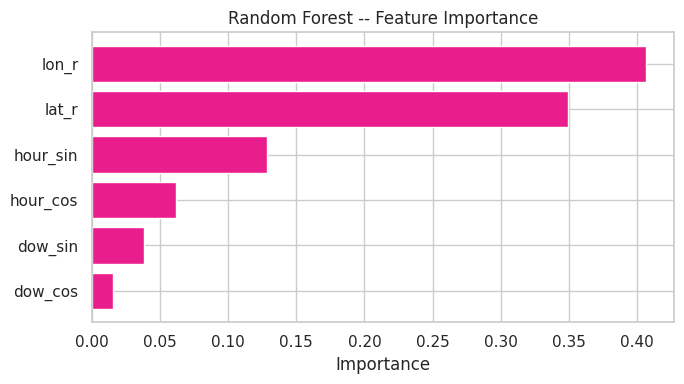

In [17]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances["feature"], importances["importance"], color="#E91E8C")
ax.set_title("Random Forest -- Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()


## 4.3 XGBoost

Tree dibangun berurutan, tiap tree baru belajar memperbaiki residual (sisa
kesalahan) dari gabungan tree-tree sebelumnya, bukan target aslinya lagi.

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"MAE  : {mae_xgb:.3f}")
print(f"RMSE : {rmse_xgb:.3f}")


MAE  : 2.915
RMSE : 3.931


# 5. Model Evaluation & Comparison

Semua model (+ baseline) dibandingkan di test set yang sama; satu-satunya
perbandingan yang adil, karena semuanya dievaluasi di baris yang belum
pernah mereka lihat.

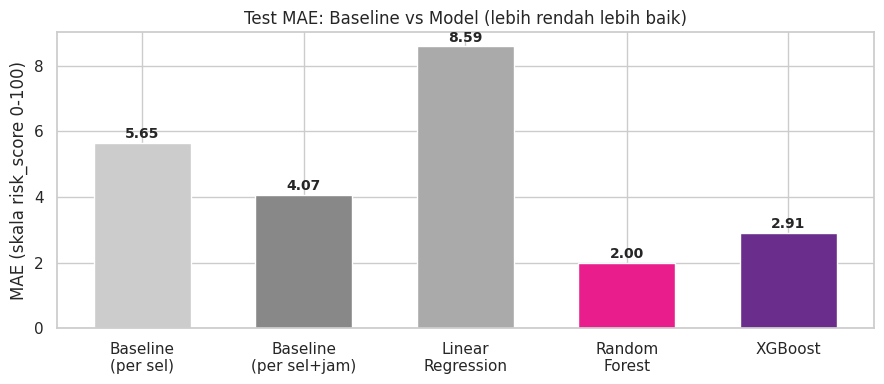

In [19]:
mae_cellhour = baseline_variants["Per (sel, jam)"]["MAE"]
rmse_cellhour = baseline_variants["Per (sel, jam)"]["RMSE"]

results = {
    "Baseline\n(per sel)": mae_cellmean,
    "Baseline\n(per sel+jam)": mae_cellhour,
    "Linear\nRegression": mae_lr,
    "Random\nForest": mae_rf,
    "XGBoost": mae_xgb,
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#CCCCCC", "#888888", "#AAAAAA", "#E91E8C", "#6B2D8B"]
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("MAE (skala risk_score 0-100)")
ax.set_title("Test MAE: Baseline vs Model (lebih rendah lebih baik)")
plt.tight_layout(); plt.show()

In [20]:
summary = pd.DataFrame({
    "Model": ["Baseline (per sel)", "Baseline (per sel+jam)", "Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_cellmean, mae_cellhour, mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_cellmean, rmse_cellhour, rmse_lr, rmse_rf, rmse_xgb],
}).round(3)
summary

,Model,MAE,RMSE
0,Baseline (per sel),5.653,7.157
1,Baseline (per sel+jam),4.071,6.072
2,Linear Regression,8.591,11.292
3,Random Forest,1.999,2.929
4,XGBoost,2.915,3.931


**Hasil aktual dari Bab 5:**

| Model | MAE | RMSE |
|---|---|---|
| Baseline (per sel) | 5,65 | 7,16 |
| Baseline (per sel + jam) | 4,07 | 6,07 |
| Linear Regression | 8,59 | 11,29 |
| Random Forest | 2,00 | 2,93 |
| XGBoost | 2,92 | 3,93 |

Beberapa temuan:

- **Linear Regression lebih buruk dari KEDUA baseline** (8,59 vs 5,65 dan 4,07). Ini masuk
  akal: Linear Regression memaksa hubungan garis lurus antar fitur dan target, padahal
  `hour_sin`/`hour_cos`/`lat_r`/`lon_r` punya hubungan yang jelas non-linear dan penuh
  interaksi (pola jam sibuk beda-beda tiap lokasi). Kedua baseline yang "curang sedikit"
  (tahu identitas sel dan/atau jam secara langsung) justru menang lawan model linear yang
  terlalu kaku.
- **Random Forest jadi yang terbaik secara jelas** (MAE 2,00), mengalahkan baseline
  tertinggi sekalipun (per sel+jam, MAE 4,07) dengan margin lebih dari 2 poin — bukti model
  ini benar-benar menangkap sesuatu di luar rata-rata historis sederhana, bukan sekadar
  meniru pola yang sudah kelihatan dari baseline.
- **XGBoost sedikit di bawah Random Forest** (2,92 vs 2,00) dengan parameter
  default/belum di-*tuning*. Ini bukan berarti XGBoost "kalah" secara umum — kemungkinan
  besar butuh *tuning* hyperparameter (`n_estimators`, `learning_rate`, `max_depth`) untuk
  menyalip Random Forest di dataset spesifik ini.

**Model yang dipilih untuk dipakai di tahap Continual Learning & API Serving berikutnya:
Random Forest**, berdasarkan MAE terendah di test set ini.

## 5.1 Diagnostik Residual

Angka MAE/RMSE meringkas performa jadi satu angka, tapi bisa menyembunyikan pola
kesalahan yang sistematis (misalnya model selalu meleset ke arah tertentu untuk nilai
tinggi). Tiga diagnostik berikut memeriksa itu untuk ketiga model.

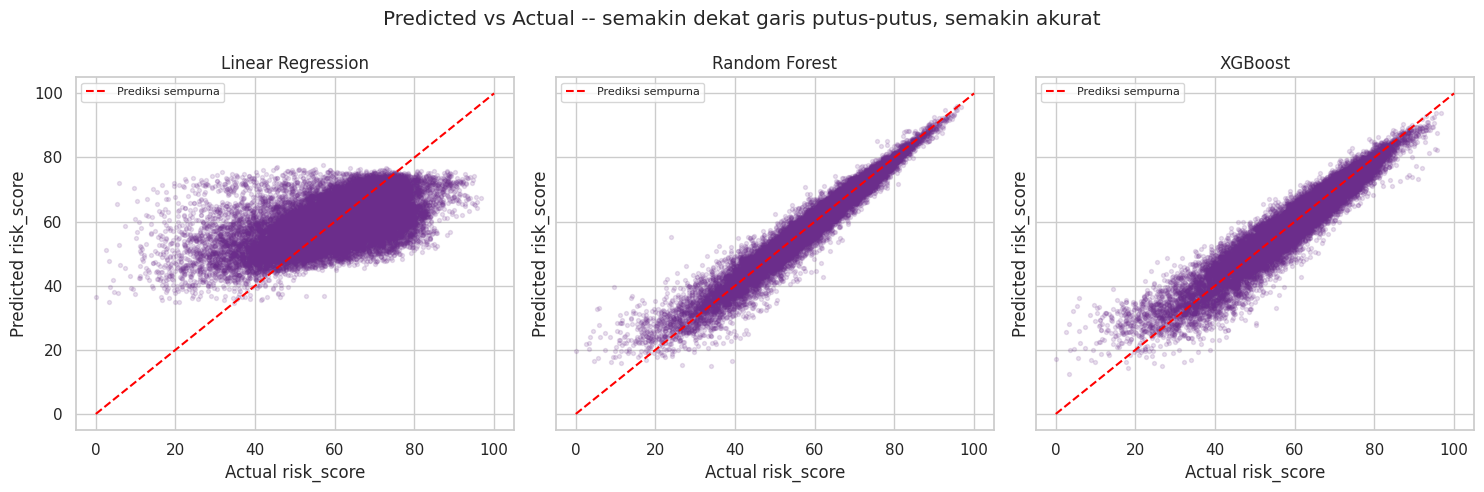

In [21]:
preds = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.15, s=8, color="#6B2D8B")
    ax.plot([0, 100], [0, 100], "--", color="red", linewidth=1.5, label="Prediksi sempurna")
    ax.set_title(name)
    ax.set_xlabel("Actual risk_score")
    ax.set_ylabel("Predicted risk_score")
    ax.legend(fontsize=8)
plt.suptitle("Predicted vs Actual -- semakin dekat garis putus-putus, semakin akurat")
plt.tight_layout(); plt.show()

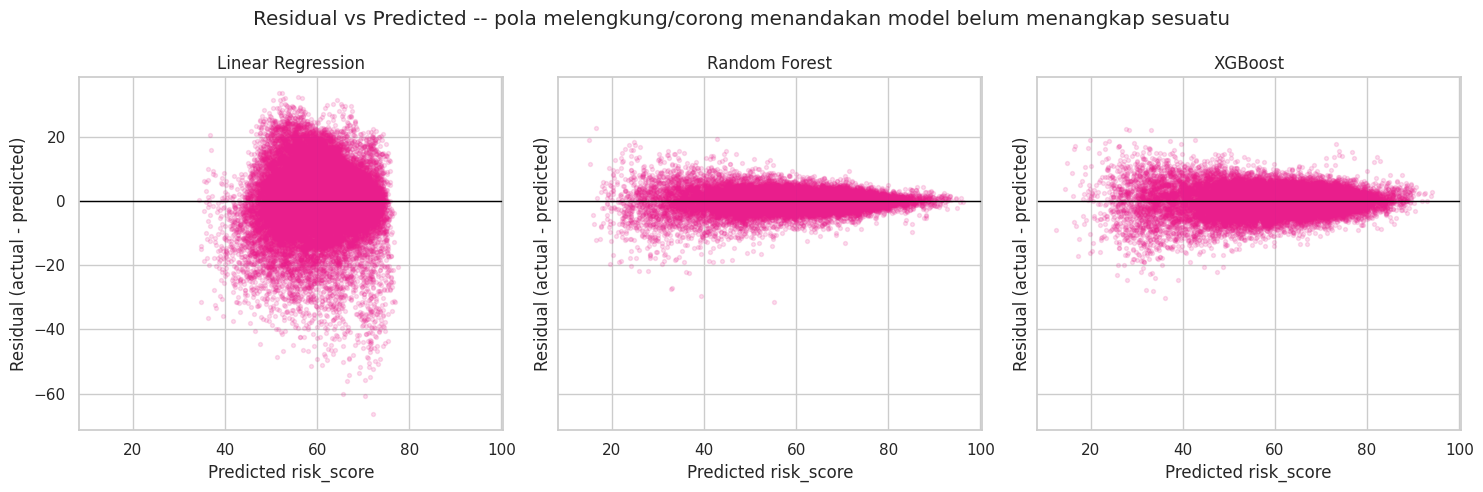

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.15, s=8, color="#E91E8C")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Predicted risk_score")
    ax.set_ylabel("Residual (actual - predicted)")
plt.suptitle("Residual vs Predicted -- pola melengkung/corong menandakan model belum menangkap sesuatu")
plt.tight_layout(); plt.show()

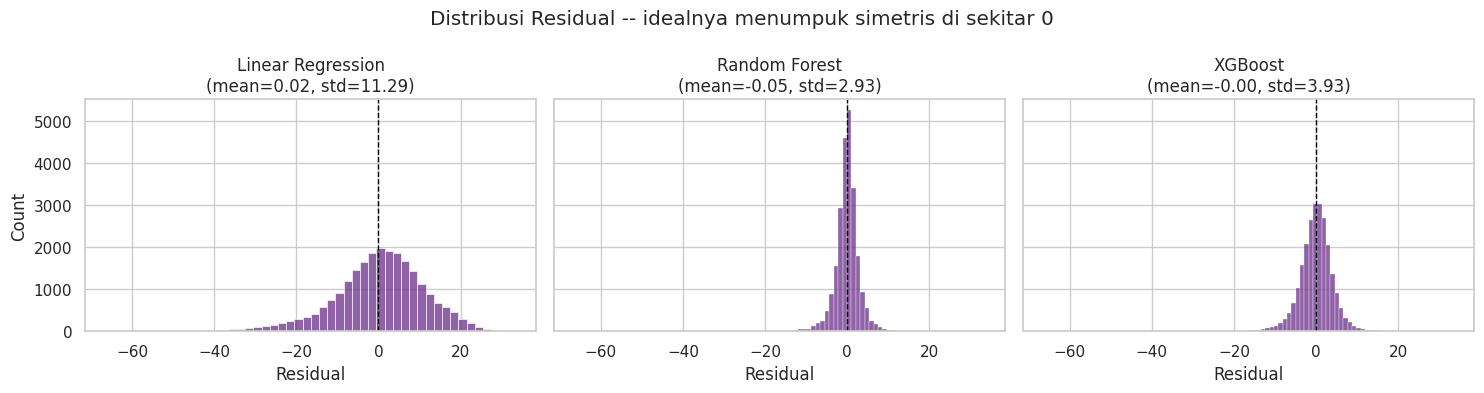

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=50, ax=ax, color="#6B2D8B")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{name}\n(mean={residuals.mean():.2f}, std={residuals.std():.2f})")
    ax.set_xlabel("Residual")
plt.suptitle("Distribusi Residual -- idealnya menumpuk simetris di sekitar 0")
plt.tight_layout(); plt.show()

**Cara membaca ketiga grafik di atas:**

- **Predicted vs Actual** — Random Forest & XGBoost jauh lebih rapat mengikuti garis
  diagonal (prediksi sempurna) dibanding Linear Regression, yang titik-titiknya lebih
  menyebar jauh dari garis -- konsisten dengan MAE-nya yang jauh lebih tinggi.
- **Residual vs Predicted** — kalau titik-titiknya membentuk pola melengkung atau corong
  (menyempit/melebar seiring nilai prediksi), itu tanda model belum menangkap sebagian pola
  data (heteroskedastisitas). Idealnya titik-titik tersebar acak di sekitar garis 0 tanpa
  pola tertentu.
- **Distribusi Residual** — idealnya menumpuk simetris di sekitar 0 (rata-rata residual
  mendekati nol, tidak condong ke satu sisi). Residual yang condong ke satu arah
  menandakan model punya bias sistematis (misalnya selalu menaksir terlalu rendah untuk
  sel-sel berisiko tinggi).

# 6. Refleksi Kritis: Kenapa MAE Random Forest Serendah Ini?

MAE 2,00 dari skala 0-100 terlihat **sangat rendah** — cukup rendah sampai
perlu dicurigai dulu sebelum dianggap sebagai kabar baik begitu saja. Bagian
ini menjelaskan kenapa angka ini masuk akal (bukan bug), sekaligus batasan
yang perlu jujur diakui.

In [24]:
# Cek: seberapa besar risk_score bervariasi ANTAR jam/hari untuk sel yang sama,
# dibanding variasi ANTAR sel yang berbeda?
variasi_dalam_sel   = df.groupby("cell_id")["risk_score"].std().mean()
variasi_antar_sel   = df.groupby("cell_id")["risk_score"].mean().std()

print(f"Rata-rata std risk_score DALAM satu sel (antar jam/hari) : {variasi_dalam_sel:.2f}")
print(f"Std rata-rata risk_score ANTAR sel                       : {variasi_antar_sel:.2f}")


Rata-rata std risk_score DALAM satu sel (antar jam/hari) : 7.16
Std rata-rata risk_score ANTAR sel                       : 14.57


**Penjelasan:** `risk_score` di CP1 dibentuk lewat *spatial smoothing* —
nilai satu sel dihitung dari rata-rata berbobot sel itu sendiri **dan**
sel-sel tetangganya dalam radius 4.500 m. Konsekuensinya, `risk_score`
menjadi fungsi yang sangat mulus terhadap posisi (`lat_r`, `lon_r`): sel-sel
yang berdekatan otomatis punya `risk_score` yang mirip, sesuai desain
smoothing itu sendiri.

Bandingkan dua angka di atas: variasi risk_score **dalam satu sel** (antar
jam/hari berbeda) jauh lebih kecil dibanding variasi **antar sel yang
berbeda**. Artinya, begitu model tahu **di sel mana** sebuah baris berada
(lewat `lat_r`/`lon_r`), sebagian besar informasi untuk menebak
`risk_score`-nya sudah didapat — Random Forest dengan 200 pohon punya cukup
kapasitas untuk hafal/mendekati pemetaan hampir-1-ke-1 dari (`lat_r`,
`lon_r`) ke rata-rata `risk_score` sel tersebut, sehingga MAE-nya sangat
kecil.

**Apakah ini masalah?** Tidak — ini bukan data leakage seperti `crime_count`
di Bab 3 (semua fitur di sini benar-benar tersedia sebelum waktu prediksi
terjadi, konsisten training vs serving). Tapi ini **penting untuk dinarasikan
dengan jujur** di laporan: MAE serendah ini sebagian besar mencerminkan
keberhasilan model mendekati fungsi *smoothing* yang sudah dibangun di CP1
(risk_score sangat prediktif dari lokasi semata), bukan semata-mata
"menemukan pola tersembunyi" yang rumit. Nilai tambah model di sini lebih ke
arah **menangkap pola temporal halus** (variasi jam/hari dalam satu sel, yang
kecil tapi tetap ada) di atas fondasi spasial yang memang sudah sangat
informatif — sesuatu yang tidak bisa ditangkap baseline per sel murni (yang
mengabaikan jam/hari sama sekali).

Feature importance di Bab 4.2 mendukung interpretasi ini: `lat_r`/`lon_r`
mendominasi, dengan `hour_sin`/`hour_cos` menyumbang porsi lebih kecil namun
tidak nol.